# CMPE 256 — Research Paper Citation Recommender
### Building the Dataset & Evaluating a Baseline Model

**Goal:** Given a research paper, recommend the papers most likely to be cited alongside it —
useful for researchers discovering related work and for understanding the structure of the ML literature.

**Why this approach:** Citation links encode semantic similarity in a way that plain text search misses.
Two papers on the same topic may share no vocabulary but appear together in thousands of reference lists.
We can exploit this co-citation signal with collaborative filtering and compare it against a pure
content-based TF-IDF baseline to measure the gain from structural information.

| Section | What we do |
|---|---|
| **1 — Data Gathering** | Fetch 300-400k paper metadata records from arXiv OAI-PMH |
| **2 — Citation Links** | Fetch citation edges for each paper from Semantic Scholar |
| **3 — Data Merging** | Join both sources, remove cold-start papers, build integer index |
| **4 — EDA** | Understand paper distribution, citation graph structure, and coverage |
| **5 — Baseline Model** | TF-IDF cosine similarity; evaluate Precision / Recall / NDCG@K |

**Output files** (saved to Google Drive):

| File | Contents |
|---|---|
| `papers.csv` | paper_idx, arxiv_id, title, abstract, text, categories, year, s2_fields, cite_pop |
| `citations.csv` | source_idx, target_idx (integer indices, in-sample only) |
| `citation_pop.csv` | citation popularity scores for the popularity baseline |

## Libraries, imports Setup

In [1]:
!pip install -q sickle tqdm

In [3]:
# all libraries needed

import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import requests

#general libraries needed
import math, random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#modelling libraries
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import networkx as nx

import implicit

print(f"numpy {np.__version__} | pandas {pd.__version__}")
print("Ready.")

numpy 1.26.4 | pandas 2.2.2
Ready.


---
## Google Drive Setup -- **to remove later**

I've mounted Google Drive here so the final dataset gets saved permanently.
All three output CSVs and the checkpoints go to the folder below —
we can pick up any interrupted run without re-fetching from scratch.

In [4]:
from google.colab import drive
drive.mount("/content/drive")

OUTPUT_DIR = Path("/content/drive/MyDrive/cmpe_256_project_files")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"output directory: {OUTPUT_DIR}")

Mounted at /content/drive
output directory: /content/drive/MyDrive/cmpe_256_project_files


### Check for existing dataset

I've added a Drive check before doing anything expensive. If `papers.csv` and `citations.csv`
already exist there, we can load them directly and skip Sections 1-3 entirely.
Section 4 EDA and Section 5 baseline always run on whatever dataset is loaded here.

In [5]:
_papers_path = OUTPUT_DIR / "papers.csv"
_cits_path   = OUTPUT_DIR / "citations.csv"

if _papers_path.exists() and _cits_path.exists():
    # dtype=str for arxiv_id columns: IDs like "2301.12345" look like floats
    # and pandas would silently parse them as float64, breaking all set lookups.
    df_papers_f = pd.read_csv(_papers_path, dtype={"arxiv_id": str})
    df_cit_f    = pd.read_csv(_cits_path,   dtype={"source_id": str, "target_id": str})
    SKIP_PIPELINE = True
    print("found existing dataset in Google Drive:")
    print(f"  papers.csv    : {len(df_papers_f):,} rows")
    print(f"  citations.csv : {len(df_cit_f):,} rows")
    print("\nskipping Sections 1-3 -- jump to Section 4 for EDA")
else:
    SKIP_PIPELINE = False
    print("no existing dataset found in Drive -- will run the full pipeline")

found existing dataset in Google Drive:
  papers.csv    : 163,275 rows
  citations.csv : 1,910,207 rows

skipping Sections 1-3 -- jump to Section 4 for EDA


In [ ]:
# I've put all tunable settings here so we can adjust them in one place.

# arXiv subcategories I've focused on (ML and related CS fields)
TARGET_CATS: set[str] = {"cs.LG", "cs.AI", "cs.CV", "cs.IR", "cs.CL", "stat.ML"}

# submission year range — I've extracted the year from the arXiv ID, not update_date
MIN_YEAR: int = 2018
MAX_YEAR: int = 2024

# expected unique papers after dedup: ~300-400k (cs + stat dominate, eess adds a few)
# 1M is the ceiling so we never sample down — we collect everything that matches
MAX_PAPERS: int = 1_000_000

# I've dropped papers below this degree so we can avoid cold-start noise in the CF models
MIN_DEGREE: int = 2

# --- Semantic Scholar ---
# I've read the API key from Colab Secrets (Secrets panel → key: SEMANTIC_API_KEY).
# Rate limits by tier:
#   no key / free key (Tier 1) : 1 req/s   — S2_WORKERS=1
#   Tier 2 (request at s2.org) : 10 req/s  — set S2_RPS=9.0, S2_WORKERS=5
# A free key still helps: requests are authenticated so arXiv papers are better matched.
try:
    from google.colab import userdata as _ud
    S2_API_KEY: str = _ud.get("SEMANTIC_API_KEY") or ""
except Exception:
    S2_API_KEY: str = ""

S2_ENDPOINT: str    = "https://api.semanticscholar.org/graph/v1/paper/batch"
S2_FIELDS: str      = "references.externalIds,fieldsOfStudy"
S2_BATCH_SIZE: int  = 500
S2_RPS: float       = 0.9   # 1 req/s for free key; raise to 9.0 for Tier 2
S2_WORKERS: int     = 1     # raise to 5 only when S2_RPS > 1 (Tier 2 key)
S2_CKPT_EVERY: int  = 100   # checkpoint every N batches so we can resume mid-fetch

# --- arXiv OAI-PMH ---
# I've chosen OAI-PMH because it's the official bulk-access method and requires no credentials.
# math is excluded: ~250k records to scan for only ~5k matches (~2%) is not worth it.
OAI_ENDPOINT: str   = "http://export.arxiv.org/oai2"
OAI_SETS: list[str] = ["cs", "stat", "eess"]

# I've split work into (set × year) tasks so we can parallelise within each set.
# 3 sets × 7 years = 21 tasks, each ~60-85k records, all running concurrently.
# Reduce to 10-12 if arXiv starts returning 503s.
OAI_WORKERS: int = 21

# I've used a conditional so the Drive mount cell's OUTPUT_DIR is not overridden
# when cells run top-to-bottom in Colab (Drive mount runs before this cell).
if "OUTPUT_DIR" not in vars():
    OUTPUT_DIR = Path(".")  # local fallback; Drive mount cell sets the real path on Colab

import numpy as np
np.random.seed(256)

print("config loaded")
print(f"output dir : {OUTPUT_DIR}")
print(f"S2 API key : {'set' if S2_API_KEY else 'not set (using public rate limit)'}")

config loaded
output dir : /content/drive/MyDrive/cmpe_256_project_files
S2 API key : set


---
## Section 1 — Data Gathering: arXiv Paper Metadata

I've used the official arXiv OAI-PMH bulk-access API so we can harvest metadata at scale
without any API key setup — it's arXiv's recommended method for batch downloads.

OAI-PMH is cursor-based (resumption tokens), so a single connection to the `cs` set
fetches 600k records sequentially. I've split the work into one task per **(set × year)**
— 3 sets × 7 years = **21 parallel tasks**, each fetching ~60-85k records, so we can
complete the full fetch in minutes instead of hours.

I've also switched from `metadataPrefix="oai_dc"` to `metadataPrefix="arXiv"` which
provides a dedicated `<categories>` element with space-separated arXiv codes
(e.g. `"cs.LG stat.ML"`). The `oai_dc` format only has human-readable strings like
`"Computer Science - Machine Learning"` in `dc:subject` — those never matched our filter.

| Set | Records scanned | Expected matches | Match rate |
|---|---|---|---|
| `cs` | ~600k | ~250-300k | ~45% |
| `stat` | ~80k | ~40-50k | ~55% |
| `eess` | ~60k | ~10-15k | ~15% |

After deduplication across sets: roughly **300-400k unique papers** total.
`MAX_PAPERS=1M` means no sampling — we keep everything that matches.

Expected runtime: **3-5 minutes** (21 concurrent streams, vs 20-35 min with 3).
Reduce `OAI_WORKERS` to 10-12 if arXiv returns persistent 503 errors.

In [ ]:
def extract_year(arxiv_id: str, fallback_date: str = "") -> int | None:
    """
    Get the submission year from an arXiv ID.

    I've relied on the YYMM prefix in new-format IDs (post-2007) because it always
    reflects the v1 submission date. I've fallen back to the update_date string only
    for old-style IDs that predate this format.
    """
    match = re.match(r"^(\d{2})\d{2}\.\d+", arxiv_id)
    if match:
        yy = int(match.group(1))
        return 2000 + yy if yy < 90 else 1900 + yy
    if len(fallback_date) >= 4:
        try:
            return int(fallback_date[:4])
        except ValueError:
            pass
    return None


def clean_text(text: str | None) -> str:
    """Collapse whitespace and strip leading/trailing spaces."""
    if not text:
        return ""
    return re.sub(r"\s+", " ", text).strip()

---
### Debug: inspect a raw arXiv-prefix OAI-PMH record

I ran this cell once to confirm that `metadataPrefix="arXiv"` returns a dedicated
`<categories>` element with space-separated arXiv codes like `"cs.LG stat.ML"`.

The original code used `metadataPrefix="oai_dc"` where `dc:subject` contains
human-readable strings like `"Computer Science - Machine Learning"` instead of
category codes, which is why the regex matched only 1-2 records per set.

In [ ]:
from sickle import Sickle as _Sickle
from xml.etree.ElementTree import fromstring as _xml_parse

_ARXIV_NS_DBG = "http://arxiv.org/OAI/arXiv/"
_sickle = _Sickle(OAI_ENDPOINT)
_records = _sickle.ListRecords(
    metadataPrefix="arXiv",
    set="cs",
    **{"from": "2023-01-01", "until": "2023-01-03"},
)

# I fetched just 3 records to confirm the arXiv prefix returns clean category codes
for _i, _rec in enumerate(_records):
    print(f"--- record {_i} ---")
    print(f"header.identifier : {_rec.header.identifier}")
    _root = _xml_parse(_rec.raw)
    _el = _root.find(f".//{{{_ARXIV_NS_DBG}}}arXiv")
    if _el is not None:
        print(f"categories        : {_el.findtext(f'{{{_ARXIV_NS_DBG}}}categories')}")
        print(f"title             : {(_el.findtext(f'{{{_ARXIV_NS_DBG}}}title') or '')[:80]}")
    print()
    if _i >= 2:
        break

--- record 0 ---
header.identifier : oai:arXiv.org:1711.06529
categories        : math.NA cond-mat.mtrl-sci
title             : Variational projector augmented-wave method: theoretical analysis and preliminar

--- record 1 ---
header.identifier : oai:arXiv.org:1712.04685
categories        : math.NA cond-mat.mtrl-sci
title             : Projector augmented-wave method: an analysis in a one-dimensional setting

--- record 2 ---
header.identifier : oai:arXiv.org:1810.01329
categories        : math.NA cond-mat.mtrl-sci
title             : Discretization error cancellation in the plane-wave approximation of periodic Ha



In [ ]:
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from xml.etree.ElementTree import fromstring as _xml_parse
from tqdm.auto import tqdm

# arXiv OAI-PMH namespace for the arXiv metadata prefix
_ARXIV_NS = "http://arxiv.org/OAI/arXiv/"

# rough total record counts per set for 2018-2024 - divided by years for per-task ETA
_SET_TOTAL_EST = {
    "cs":   600_000,
    "stat":  80_000,
    "eess":  60_000,
}


def _parse_record(record) -> dict | None:
    """
    Extract one paper's fields from a sickle arXiv-prefix record.

    I switched from oai_dc to metadataPrefix="arXiv" because oai_dc puts
    human-readable strings in dc:subject (e.g. "Computer Science - Machine
    Learning") that don't match arXiv category codes. The arXiv prefix has a
    dedicated <categories> element with space-separated codes like "cs.LG stat.ML",
    so we get exact matches against TARGET_CATS without any fragile regex.

    Returns None if the record did not match target categories or year range.
    """
    try:
        oai_id = record.header.identifier
        arxiv_id = re.sub(r"v\d+$", "", oai_id.split("oai:arXiv.org:")[-1]).strip()
        if not arxiv_id:
            return None

        year = extract_year(arxiv_id)
        if year is None or not (MIN_YEAR <= year <= MAX_YEAR):
            return None

        root = _xml_parse(record.raw)
        arxiv_el = root.find(f".//{{{_ARXIV_NS}}}arXiv")
        if arxiv_el is None:
            return None

        cats_str = (arxiv_el.findtext(f"{{{_ARXIV_NS}}}categories") or "").strip()
        cats = cats_str.split()
        if not set(cats) & TARGET_CATS:
            return None

        title = clean_text(arxiv_el.findtext(f"{{{_ARXIV_NS}}}title") or "")
        abstract = clean_text(arxiv_el.findtext(f"{{{_ARXIV_NS}}}abstract") or "")

        authors_list = []
        for author_el in arxiv_el.findall(
            f"{{{_ARXIV_NS}}}authors/{{{_ARXIV_NS}}}author"
        ):
            keyname = author_el.findtext(f"{{{_ARXIV_NS}}}keyname") or ""
            forenames = author_el.findtext(f"{{{_ARXIV_NS}}}forenames") or ""
            if keyname:
                authors_list.append(f"{forenames} {keyname}".strip())

        return {
            "arxiv_id":   arxiv_id,
            "title":      title,
            "abstract":   abstract,
            "categories": " ".join(cats),
            "authors":    "; ".join(authors_list),
            "year":       year,
        }
    except Exception:
        return None


def _fetch_year(oai_set: str, year: int) -> tuple[str, int, list[dict]]:
    """
    Fetch all matching papers from one OAI-PMH set for a single calendar year.

    I check OUTPUT_DIR for a per-task checkpoint first. If the file exists we
    load and return immediately, so a resumed run skips all already-finished
    (set, year) pairs without hitting the OAI-PMH server at all.

    After a successful live fetch I write the results to a .tmp file and rename
    it into place atomically, so a session crash mid-write never leaves a corrupt
    checkpoint that would be silently loaded on the next run.

    Returns (oai_set, year, rows) so the caller can log per-task completions.
    """
    ckpt_path = OUTPUT_DIR / f"_ckpt_oai_{oai_set}_{year}.csv"

    if ckpt_path.exists():
        # dtype=str: arXiv IDs like "2301.12345" look like floats to pandas and
        # would be read as float64 without this, breaking all set/isin lookups.
        rows = pd.read_csv(ckpt_path, dtype=str).to_dict("records")
        tqdm.write(f"  [{oai_set}/{year}] checkpoint: {len(rows):,} papers (skipping fetch)")
        return oai_set, year, rows

    from sickle import Sickle

    sickle = Sickle(OAI_ENDPOINT, max_retries=3, retry_status_codes=[503, 429])
    rows: list[dict] = []
    n_years = MAX_YEAR - MIN_YEAR + 1
    est = _SET_TOTAL_EST.get(oai_set, 100_000) // n_years

    try:
        records = sickle.ListRecords(
            metadataPrefix="arXiv",
            set=oai_set,
            **{"from": f"{year}-01-01", "until": f"{year}-12-31"},
        )
        with tqdm(
            records,
            desc=f"  {oai_set}/{year}",
            total=est,
            leave=False,
            unit=" rec",
            dynamic_ncols=True,
        ) as pbar:
            for record in pbar:
                row = _parse_record(record)
                if row:
                    rows.append(row)
                pbar.set_postfix(kept=f"{len(rows):,}")

    except Exception as exc:
        tqdm.write(f"  [{oai_set}/{year}] stopped: {type(exc).__name__}: {exc}")

    # atomic write: .tmp then rename so a crash mid-write never corrupts the checkpoint
    if rows:
        tmp = ckpt_path.with_suffix(".tmp")
        pd.DataFrame(rows).to_csv(tmp, index=False)
        tmp.rename(ckpt_path)

    tqdm.write(f"  [{oai_set}/{year}] done: {len(rows):,} matched : saved to {ckpt_path.name}")
    return oai_set, year, rows


def load_oai_arxiv(
    min_year: int = MIN_YEAR,
    max_year: int = MAX_YEAR,
    max_papers: int | None = MAX_PAPERS,
    oai_sets: list[str] | None = None,
    workers: int = OAI_WORKERS,
) -> pd.DataFrame:
    """
    Fetch arXiv paper metadata from OAI-PMH with concurrent per-(set, year) streams.

    I split the work into one task per (set × year) pair so we can use up to 21
    parallel workers instead of just 3. Tasks that already have a checkpoint file
    in OUTPUT_DIR are loaded instantly and skipped, so a resumed run only fetches
    whatever was not yet completed when the session ended.

    Args:
        min_year: Earliest submission year to include (inclusive).
        max_year: Latest submission year to include (inclusive).
        max_papers: Cap on total unique papers. None means keep all.
        oai_sets: OAI-PMH top-level set names. Defaults to OAI_SETS.
        workers: Number of parallel threads.

    Returns:
        DataFrame with columns: arxiv_id, title, abstract, categories, authors, year.
    """
    if oai_sets is None:
        oai_sets = OAI_SETS

    tasks = [(s, y) for s in oai_sets for y in range(min_year, max_year + 1)]
    n_years = max_year - min_year + 1

    n_cached = sum(
        1 for s, y in tasks
        if (OUTPUT_DIR / f"_ckpt_oai_{s}_{y}.csv").exists()
    )
    print(
        f"launching {len(tasks)} tasks "
        f"({len(oai_sets)} sets × {n_years} years) with {workers} workers"
    )
    print(f"  checkpoints : {OUTPUT_DIR}")
    print(f"  cached      : {n_cached}/{len(tasks)} tasks will load from file\n")

    all_rows: list[dict] = []

    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {pool.submit(_fetch_year, s, y): (s, y) for s, y in tasks}
        with tqdm(total=len(tasks), desc="tasks completed", unit=" task") as outer:
            for future in as_completed(futures):
                _, _, rows = future.result()
                all_rows.extend(rows)
                outer.update(1)
                outer.set_postfix(total_kept=f"{len(all_rows):,}")

    df = (
        pd.DataFrame(all_rows)
        .drop_duplicates(subset="arxiv_id")
        .reset_index(drop=True)
    )
    if max_papers and len(df) > max_papers:
        df = df.sample(n=max_papers, random_state=256).reset_index(drop=True)

    print(f"\nloaded {len(df):,} unique papers total")
    return df

In [ ]:
if not SKIP_PIPELINE:
    # I kicked off the concurrent fetch here.
    # Each set prints its own progress so we can see all four streams running at once.
    df_papers = load_oai_arxiv()

In [ ]:
if not SKIP_PIPELINE:
    # I ran a quick sanity check before moving on to catch any obvious issues early.
    print(f"shape         : {df_papers.shape}")
    print(f"null titles   : {df_papers['title'].isna().sum()}")
    print(f"null abstracts: {df_papers['abstract'].isna().sum()}")
    print(f"year range    : {df_papers['year'].min()} - {df_papers['year'].max()}")
    display(df_papers.head(3))

---
## Section 2: Fetching Citation Links from Semantic Scholar

arXiv does not have citation data, so I used the Semantic Scholar batch API.
For each paper in my dataset, S2 returned the list of papers it referenced
along with their arXiv IDs when available. I sent 500 paper IDs per request
to maximize throughput within each API call.

**Rate limiting:** S2 enforces ~1 req/s on the public endpoint. I used a shared
`_S2RateLimiter` token bucket across all worker threads so the combined rate
never exceeds the limit regardless of worker count.

**Speeding this up:** Get a free API key at `semanticscholar.org/product/api` —
it unlocks approx 10 req/s. Then set `S2_API_KEY`, `S2_RPS=9.0`, `S2_WORKERS=5`
in the config cell for roughly 10× faster fetching (~4 min instead of ~40 min
for 300k papers).

The progress bar shows live links found, S2 coverage %, actual req/s, and a
rolling ETA. Any 429 responses are retried once after honoring the `Retry-After`
header, and failed batches are counted and reported at the end.

In [ ]:
import threading


class _S2RateLimiter:
    """
    Thread-safe token bucket that spaces S2 requests to at most `rps` per second.

    I used a shared lock so all workers compete for the same rate budget rather
    than each sleeping independently, which would let the combined rate exceed
    the S2 limit and trigger 429s.
    """
    def __init__(self, rps: float):
        self._interval = 1.0 / rps
        self._lock = threading.Lock()
        self._next_allowed = 0.0

    def acquire(self) -> None:
        with self._lock:
            now = time.monotonic()
            wait = self._next_allowed - now
            if wait > 0:
                time.sleep(wait)
            self._next_allowed = time.monotonic() + self._interval


def fetch_s2_batch(
    arxiv_ids: list[str],
    headers: dict | None = None,
    endpoint: str = S2_ENDPOINT,
    fields: str = S2_FIELDS,
) -> tuple[list[tuple[str, str]], dict[str, str]]:
    """
    Fetch one batch of citation data from Semantic Scholar.

    Args:
        arxiv_ids: List of arXiv IDs (no version suffix).
        headers: Optional request headers (e.g. {"x-api-key": key}).
        endpoint: S2 batch API URL.
        fields: Comma-separated fields to request.

    Returns:
        citation_pairs: List of (source_id, target_id) tuples.
        fields_map: Dict of arxiv_id -> fields-of-study string.

    Raises:
        requests.HTTPError: On non-200 response.
    """
    resp = requests.post(
        endpoint,
        params={"fields": fields},
        json={"ids": [f"arXiv:{pid}" for pid in arxiv_ids]},
        headers=headers or {},
        timeout=60,
    )
    resp.raise_for_status()

    pairs: list[tuple[str, str]] = []
    fields_map: dict[str, str] = {}

    for src_id, paper in zip(arxiv_ids, resp.json()):
        if paper is None:
            continue
        fos = paper.get("fieldsOfStudy") or []
        if fos:
            fields_map[src_id] = ", ".join(fos)
        for ref in paper.get("references") or []:
            cited = (ref.get("externalIds") or {}).get("ArXiv")
            if cited:
                pairs.append((src_id, re.sub(r"v\d+$", "", cited.strip())))

    return pairs, fields_map


def _fetch_batch_safe(
    batch_idx: int,
    arxiv_ids: list[str],
    limiter: _S2RateLimiter,
    headers: dict,
) -> tuple[int, list[str], list[tuple[str, str]], dict[str, str], bool]:
    """
    Fetch one S2 batch with rate-limit enforcement and a single 429 retry.

    I respected the Retry-After header on 429s instead of using a fixed backoff
    so we wait exactly as long as S2 asks and don't over-sleep.

    Returns (batch_idx, arxiv_ids, pairs, fields_map, ok). Passing arxiv_ids back
    lets the caller mark those IDs as done in the checkpoint without maintaining
    a separate batch-index-to-IDs mapping.
    ok=False means the whole batch failed — its IDs are NOT added to the done set
    so they will be retried on the next run.
    """
    for attempt in range(2):
        limiter.acquire()
        try:
            pairs, fmap = fetch_s2_batch(arxiv_ids, headers=headers)
            return batch_idx, arxiv_ids, pairs, fmap, True

        except requests.HTTPError as exc:
            status = exc.response.status_code
            if status == 429:
                retry_after = int(exc.response.headers.get("Retry-After", 30))
                tqdm.write(
                    f"  [429] batch {batch_idx}: "
                    f"rate limited — sleeping {retry_after}s then retrying"
                )
                time.sleep(retry_after)
                continue
            tqdm.write(f"  [HTTP {status}] batch {batch_idx}: skipped")
            return batch_idx, arxiv_ids, [], {}, False

        except Exception as exc:
            tqdm.write(f"  [error] batch {batch_idx}: {type(exc).__name__}: {exc}")
            return batch_idx, arxiv_ids, [], {}, False

    tqdm.write(f"  [failed] batch {batch_idx}: gave up after 429 retry")
    return batch_idx, arxiv_ids, [], {}, False

In [ ]:
def fetch_s2_citations(
    arxiv_ids: list[str],
    batch_size: int = S2_BATCH_SIZE,
    rps: float = S2_RPS,
    workers: int = S2_WORKERS,
    api_key: str = S2_API_KEY,
    ckpt_every: int = S2_CKPT_EVERY,
) -> tuple[pd.DataFrame, dict[str, str]]:
    """
    Fetch all citation links from Semantic Scholar with parallel workers, a shared
    rate limiter, and incremental checkpointing to Google Drive.

    I save three checkpoint files to OUTPUT_DIR every `ckpt_every` completed batches:
      _ckpt_s2_pairs.csv   -- all citation pairs collected so far
      _ckpt_s2_fields.json -- fields-of-study map collected so far
      _ckpt_s2_done.json   -- sorted list of arxiv_ids successfully sent to S2

    Checkpoint staleness check: before trusting the checkpoint I verify that at
    least 50% of the current arxiv_ids appear in the saved done set. A lower
    overlap means the checkpoint is from a different OAI-PMH run (different paper
    set) and would produce source IDs that don't match df_papers, causing 0
    in-sample citations. In that case I discard the checkpoint and start fresh.

    All checkpoint writes use .tmp and rename to prevent partial files on crash.
    Failed batches (ok=False) are NOT marked done so they are retried on next run.

    Args:
        arxiv_ids: All arXiv IDs to look up.
        batch_size: IDs per request (S2 max is 500).
        rps: Max requests per second shared across all workers.
        workers: Concurrent fetch threads.
        api_key: Optional S2 API key.
        ckpt_every: Save checkpoint every N completed batches.

    Returns:
        df_citations: DataFrame with columns source_id, target_id.
        s2_fields_map: Dict of arxiv_id -> fields-of-study string.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed

    ckpt_pairs  = OUTPUT_DIR / "_ckpt_s2_pairs.csv"
    ckpt_fields = OUTPUT_DIR / "_ckpt_s2_fields.json"
    ckpt_done   = OUTPUT_DIR / "_ckpt_s2_done.json"

    # --- resume from checkpoint if available ---
    all_pairs: list[tuple[str, str]] = []
    s2_fields_map: dict[str, str] = {}
    done_ids: set[str] = set()

    if ckpt_done.exists():
        saved_done = set(json.loads(ckpt_done.read_text()))
        current_ids = set(arxiv_ids)
        overlap_frac = len(saved_done & current_ids) / max(len(current_ids), 1)

        if overlap_frac < 0.5:
            # checkpoint is from a different OAI-PMH run — source IDs won't match
            # current df_papers, which would cause 0 in-sample citations downstream
            print(
                f"  stale S2 checkpoint: only {overlap_frac:.0%} of current IDs found in saved set\n"
                f"  discarding checkpoint and starting fresh"
            )
        else:
            done_ids = saved_done & current_ids  # only keep IDs relevant to this run
            if ckpt_pairs.exists():
                # dtype=str: arXiv IDs like "2301.12345" parse as float64 without this,
                # making isin() comparisons with string paper_ids return all-False
                _df = pd.read_csv(ckpt_pairs, dtype={"source_id": str, "target_id": str})
                # filter to pairs whose source is in the current paper set
                _df = _df[_df["source_id"].isin(current_ids)]
                all_pairs = list(zip(_df["source_id"], _df["target_id"]))
            if ckpt_fields.exists():
                s2_fields_map = json.loads(ckpt_fields.read_text())

    # --- build batch list and skip already-done batches ---
    all_batches = [
        arxiv_ids[i : i + batch_size]
        for i in range(0, len(arxiv_ids), batch_size)
    ]
    pending = [
        (i, batch) for i, batch in enumerate(all_batches)
        if not done_ids.issuperset(batch)
    ]
    n_skipped = len(all_batches) - len(pending)

    print(f"S2 citation fetch")
    print(f"  papers    : {len(arxiv_ids):,}")
    print(f"  batches   : {len(all_batches):,} total | {n_skipped:,} already done | {len(pending):,} to fetch")
    print(f"  rate      : {rps} req/s  |  workers: {workers}")
    print(f"  ETA       : ~{len(pending) / rps / 60:.0f} min")
    print(f"  checkpoint: every {ckpt_every} batches → {OUTPUT_DIR}")
    if done_ids:
        print(f"  resumed   : {len(done_ids):,} IDs already processed | {len(all_pairs):,} pairs loaded")
    if not api_key:
        print(
            "  tip: a free S2 API key unlocks higher rate limits → "
            "set S2_API_KEY, S2_RPS, S2_WORKERS"
        )
    print()

    def _save_checkpoint() -> None:
        """Atomically write all three checkpoint files."""
        for path, write_fn in [
            (ckpt_pairs,  lambda p: pd.DataFrame(all_pairs, columns=["source_id", "target_id"]).to_csv(p, index=False)),
            (ckpt_fields, lambda p: p.write_text(json.dumps(s2_fields_map))),
            (ckpt_done,   lambda p: p.write_text(json.dumps(sorted(done_ids)))),
        ]:
            tmp = path.with_suffix(".tmp")
            write_fn(tmp)
            tmp.rename(path)

    if not pending:
        print("all batches already checkpointed — skipping S2 fetch")
        df_cit = pd.DataFrame(all_pairs, columns=["source_id", "target_id"])
        return df_cit, s2_fields_map

    headers = {"x-api-key": api_key} if api_key else {}
    limiter = _S2RateLimiter(rps)
    n_failed = 0
    n_since_ckpt = 0
    t_start = time.monotonic()

    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {
            pool.submit(_fetch_batch_safe, i, batch, limiter, headers): i
            for i, batch in pending
        }
        with tqdm(
            total=len(pending),
            desc="S2 batches",
            unit=" batch",
            dynamic_ncols=True,
        ) as pbar:
            for future in as_completed(futures):
                idx, batch_ids, pairs, fmap, ok = future.result()
                all_pairs.extend(pairs)
                s2_fields_map.update(fmap)
                if ok:
                    done_ids.update(batch_ids)
                else:
                    n_failed += 1

                n_since_ckpt += 1
                if n_since_ckpt >= ckpt_every:
                    _save_checkpoint()
                    n_since_ckpt = 0
                    tqdm.write(
                        f"  checkpoint saved: {len(all_pairs):,} pairs | "
                        f"{len(done_ids):,} IDs done"
                    )

                elapsed = time.monotonic() - t_start
                done = pbar.n + 1
                req_rate = done / elapsed if elapsed > 0 else 0
                remaining = (len(pending) - done) / req_rate if req_rate > 0 else 0
                pbar.update(1)
                pbar.set_postfix(
                    links=f"{len(all_pairs):,}",
                    coverage=f"{100 * len(s2_fields_map) / len(arxiv_ids):.1f}%",
                    req_s=f"{req_rate:.2f}",
                    eta=f"{remaining / 60:.1f}m",
                    err=n_failed or "",
                )

    _save_checkpoint()

    df_cit = pd.DataFrame(all_pairs, columns=["source_id", "target_id"])
    elapsed_min = (time.monotonic() - t_start) / 60
    coverage_pct = 100 * len(s2_fields_map) / len(arxiv_ids)

    print(f"\nS2 fetch complete  ({elapsed_min:.1f} min)")
    print(f"  citation links   : {len(df_cit):,}")
    print(f"  unique sources   : {df_cit['source_id'].nunique():,}")
    print(f"  unique targets   : {df_cit['target_id'].nunique():,}")
    print(f"  S2 coverage      : {coverage_pct:.1f}%  ({len(s2_fields_map):,} / {len(arxiv_ids):,} papers)")
    avg_refs = len(df_cit) / max(df_cit["source_id"].nunique(), 1)
    print(f"  avg refs / paper : {avg_refs:.1f}")
    if n_failed:
        print(f"  failed batches   : {n_failed}  ({n_failed * batch_size:,} IDs affected — will retry on next run)")

    return df_cit, s2_fields_map

In [ ]:
if not SKIP_PIPELINE:
    arxiv_ids = df_papers["arxiv_id"].tolist()
    df_citations_raw, s2_fields_map = fetch_s2_citations(arxiv_ids)

In [ ]:
if not SKIP_PIPELINE:
    # I saved intermediate results to Google Drive so we can resume from this point
    # if Colab disconnects before Section 3 finishes.
    df_papers.to_csv(OUTPUT_DIR / "_checkpoint_papers.csv", index=False)
    df_citations_raw.to_csv(OUTPUT_DIR / "_checkpoint_citations_raw.csv", index=False)

    with open(OUTPUT_DIR / "_checkpoint_s2_fields.json", "w") as f:
        json.dump(s2_fields_map, f)

    print(f"checkpoints saved to {OUTPUT_DIR}")

---
### Resume from checkpoint (run only if Colab disconnected before Section 3)

If I had to restart my runtime after saving the checkpoints above, I loaded them
here instead of re-running Sections 1 and 2.
Skip this cell if `df_papers` and `df_citations_raw` are still in memory.

In [ ]:
if not SKIP_PIPELINE:
    _ckpt_papers = OUTPUT_DIR / "_checkpoint_papers.csv"
    _ckpt_cit    = OUTPUT_DIR / "_checkpoint_citations_raw.csv"
    _ckpt_fields = OUTPUT_DIR / "_checkpoint_s2_fields.json"

    if _ckpt_papers.exists() and _ckpt_cit.exists():
        # dtype=str prevents "2301.12345" from being read back as float64
        df_papers        = pd.read_csv(_ckpt_papers, dtype={"arxiv_id": str})
        df_citations_raw = pd.read_csv(_ckpt_cit,    dtype={"source_id": str, "target_id": str})
        s2_fields_map    = json.loads(_ckpt_fields.read_text()) if _ckpt_fields.exists() else {}
        print(f"loaded from checkpoint: {len(df_papers):,} papers, {len(df_citations_raw):,} raw links")
    else:
        print("no checkpoint files found - run Sections 1 and 2 first")

---
## Section 3: Joining arXiv and S2 Data into the Final Combined Dataset

This is where I joined the two sources into a single dataset:

- **From arXiv OAI-PMH** (Section 1): `arxiv_id`, `title`, `abstract`, `categories`, `authors`, `year`
- **From Semantic Scholar** (Section 2): `s2_fields` (field of study), `cite_pop` (normalized in-sample citation count), and the full `citations.csv` edge list

The join key is `arxiv_id`. After joining I also needed to:

1. Keep only citations where both the source and target paper were in my dataset
2. Drop papers with very few connections to avoid cold-start noise
3. Build a clean 0-based integer index so the sparse matrix models can use it directly

The output of this section is `df_papers_f` and `df_cit_f`, which are the fully combined
dataset that Section 4 runs EDA on and that we save to Google Drive.

In [ ]:
def filter_in_sample_citations(
    df_citations: pd.DataFrame,
    paper_ids: set[str],
) -> pd.DataFrame:
    """
    Keep only citations where both source and target are in paper_ids.

    I coerce source_id and target_id to str before the isin() check because
    arXiv IDs like "2301.12345" are valid floats and pandas parses them as
    float64 when reading CSVs. Without the cast, float 2301.12345 != str
    "2301.12345" and isin() returns all-False, giving 0 in-sample citations.

    I also removed self-citations and duplicate edges here so we get a clean
    directed graph with no noise before building the sparse matrix.

    Args:
        df_citations: Raw citation pairs (source_id, target_id).
        paper_ids: Set of valid arXiv IDs (strings).

    Returns:
        Filtered DataFrame.
    """
    paper_ids_str = {str(p) for p in paper_ids}
    src = df_citations["source_id"].astype(str)
    tgt = df_citations["target_id"].astype(str)
    mask = src.isin(paper_ids_str) & tgt.isin(paper_ids_str) & (src != tgt)
    return (
        df_citations[mask]
        .assign(source_id=src[mask].values, target_id=tgt[mask].values)
        .drop_duplicates()
        .reset_index(drop=True)
    )

In [ ]:
def filter_cold_start(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    min_degree: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Remove papers with fewer than min_degree total citation connections.

    I computed each paper's degree as in-degree plus out-degree. Papers below
    the threshold were cold-start cases that would hurt CF model quality because
    the matrix factorization models need at least some signal per paper to learn
    a meaningful embedding. Removing them gave us a cleaner training set.

    Args:
        df_papers: Paper metadata DataFrame.
        df_citations: In-sample citation pairs.
        min_degree: Minimum total degree to keep a paper.

    Returns:
        Filtered (df_papers, df_citations) tuple.
    """
    degree = pd.concat([
        df_citations["source_id"].value_counts(),
        df_citations["target_id"].value_counts(),
    ]).groupby(level=0).sum()

    connected = set(degree[degree >= min_degree].index)

    df_p = df_papers[df_papers["arxiv_id"].isin(connected)].reset_index(drop=True)
    remaining = set(df_p["arxiv_id"])
    df_c = df_citations[
        df_citations["source_id"].isin(remaining)
        & df_citations["target_id"].isin(remaining)
    ].reset_index(drop=True)

    n_removed = len(df_papers) - len(df_p)
    print(f"removed {n_removed:,} cold-start papers (degree < {min_degree})")
    return df_p, df_c

In [ ]:
def build_integer_index(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Add a 0-based integer paper_idx to papers and resolve it in citations.

    I chose 0-based integer indexing because scipy sparse matrices and the
    ALS/SVD libraries expect rows and columns to be contiguous integers. This
    gave us direct compatibility with those libraries without any extra mapping.

    Args:
        df_papers: Paper metadata (must have arxiv_id column).
        df_citations: Citation pairs (must have source_id, target_id columns).

    Returns:
        Updated (df_papers, df_citations) with integer index columns added.
    """
    df_p = df_papers.reset_index(drop=True).copy()
    df_p["paper_idx"] = df_p.index

    id_to_idx: dict[str, int] = dict(zip(df_p["arxiv_id"], df_p["paper_idx"]))

    df_c = df_citations.copy()
    df_c["source_idx"] = df_c["source_id"].map(id_to_idx)
    df_c["target_idx"] = df_c["target_id"].map(id_to_idx)
    df_c = df_c.dropna(subset=["source_idx", "target_idx"]).reset_index(drop=True)
    df_c[["source_idx", "target_idx"]] = df_c[["source_idx", "target_idx"]].astype(int)

    return df_p, df_c

In [ ]:
def add_computed_fields(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    s2_fields_map: dict[str, str],
) -> pd.DataFrame:
    """
    Add derived columns that the models would need.

    Columns added:
        primary_cat: First listed arXiv category.
        s2_fields: Semantic Scholar fields of study (e.g. "Computer Science").
        text: Title repeated twice + abstract. I repeated the title to give it
              higher TF-IDF weight because titles carry the most informative
              signal per word and this gave us better content similarity results.
        cite_pop: Normalized in-sample citation count from 0 to 1, used by the
                  baseline model as a popularity score.

    Args:
        df_papers: Paper metadata with paper_idx already added.
        df_citations: Filtered in-sample citations.
        s2_fields_map: Dict from arxiv_id to fields-of-study string.

    Returns:
        Updated df_papers with new columns.
    """
    df = df_papers.copy()
    df["primary_cat"] = df["categories"].str.split().str[0]
    df["s2_fields"] = df["arxiv_id"].map(s2_fields_map).fillna("")
    df["text"] = df["title"] + " " + df["title"] + " " + df["abstract"]

    raw_counts = df_citations["target_id"].value_counts()
    max_count = raw_counts.max() if len(raw_counts) > 0 else 1
    df["cite_pop"] = (
        df["arxiv_id"].map((raw_counts / max_count).to_dict()).fillna(0.0)
    )
    return df

In [ ]:
if not SKIP_PIPELINE:
    paper_ids = set(df_papers["arxiv_id"].astype(str))

    # diagnostic: show source and target overlap separately so mismatches are obvious
    src_overlap = df_citations_raw["source_id"].astype(str).isin(paper_ids).mean()
    tgt_overlap = df_citations_raw["target_id"].astype(str).isin(paper_ids).mean()
    print(f"overlap check (before filter):")
    print(f"  source_id in paper_ids : {src_overlap:.1%}  : should be ~100% (S2 queried our papers)")
    print(f"  target_id in paper_ids : {tgt_overlap:.1%}  : expected 5-20% (only same-domain papers)")
    if src_overlap < 0.9:
        print("  WARNING: source overlap is low — S2 checkpoint may be from a different OAI-PMH run")
        print("  delete _ckpt_s2_*.csv / .json from Drive and re-run Section 2")
    print()

    # Step 1: I filtered down to in-sample citations only
    df_cit_in = filter_in_sample_citations(df_citations_raw, paper_ids)

    total = len(df_citations_raw)
    kept  = len(df_cit_in)
    print(f"raw links : {total:,}")
    print(f"in-sample : {kept:,} ({100 * kept / total:.2f}%)")

In [ ]:
if not SKIP_PIPELINE:
    # Step 2: I dropped cold-start papers to give us a denser, cleaner training set
    df_papers_f, df_cit_f = filter_cold_start(df_papers, df_cit_in, min_degree=MIN_DEGREE)
    print(f"papers: {len(df_papers_f):,} | citations: {len(df_cit_f):,}")

In [ ]:
if not SKIP_PIPELINE:
    # Step 3: I built the integer index so we can plug directly into scipy and ALS
    df_papers_f, df_cit_f = build_integer_index(df_papers_f, df_cit_f)
    print(f"paper_idx range: 0 - {df_papers_f['paper_idx'].max()}")

In [ ]:
if not SKIP_PIPELINE:
    # Step 4: I joined S2 fields and citation popularity into df_papers_f.
    # After this cell df_papers_f is the final combined arXiv + S2 dataset.
    df_papers_f = add_computed_fields(df_papers_f, df_cit_f, s2_fields_map)
    print("combined dataset columns:", df_papers_f.columns.tolist())

In [ ]:
def save_datasets(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    output_dir: Path = OUTPUT_DIR,
) -> None:
    """Save the three final CSV files to output_dir (Google Drive)."""
    paper_cols = [
        "paper_idx", "arxiv_id", "title", "abstract", "text",
        "categories", "primary_cat", "year", "authors", "s2_fields", "cite_pop",
    ]
    df_papers[paper_cols].to_csv(output_dir / "papers.csv", index=False)
    print(f"papers.csv       : {len(df_papers):,} rows  ->  {output_dir / 'papers.csv'}")

    cit_cols = ["source_idx", "target_idx", "source_id", "target_id"]
    df_citations[cit_cols].to_csv(output_dir / "citations.csv", index=False)
    print(f"citations.csv    : {len(df_citations):,} rows  ->  {output_dir / 'citations.csv'}")

    pop = (
        df_citations["target_id"].value_counts()
        .reset_index()
        .rename(columns={"target_id": "arxiv_id", "count": "raw_cite_count"})
    )
    pop["cite_pop_norm"] = pop["raw_cite_count"] / pop["raw_cite_count"].max()
    pop.to_csv(output_dir / "citation_pop.csv", index=False)
    print(f"citation_pop.csv : {len(pop):,} rows  ->  {output_dir / 'citation_pop.csv'}")


if not SKIP_PIPELINE:
    # I saved to Google Drive so the dataset persists across Colab sessions
    save_datasets(df_papers_f, df_cit_f)

---
## Section 4: Exploratory Data Analysis

I ran all EDA on `df_papers_f` and `df_cit_f`, which are the fully combined arXiv + S2
dataset produced by Section 3. Every plot and stat below reflects the joined dataset
that was saved to Google Drive.

I looked at the paper distribution, citation graph structure, and coverage stats.
This helped me catch data quality issues early and gave us a sense of what the models
would be working with.

In [6]:
# I computed basic stats first to confirm the dataset looked reasonable
n_papers = len(df_papers_f)
n_citations = len(df_cit_f)

print(f"papers          : {n_papers:,}")
print(f"citation links  : {n_citations:,}")
print(f"avg refs/paper  : {n_citations / n_papers:.1f}")
print(f"null abstracts  : {(df_papers_f['abstract'].str.len() == 0).sum()}")
print(f"s2 field coverage: {(df_papers_f['s2_fields'].str.len() > 0).mean():.1%}")

papers          : 163,275
citation links  : 1,910,207
avg refs/paper  : 11.7
null abstracts  : 0
s2 field coverage: 100.0%


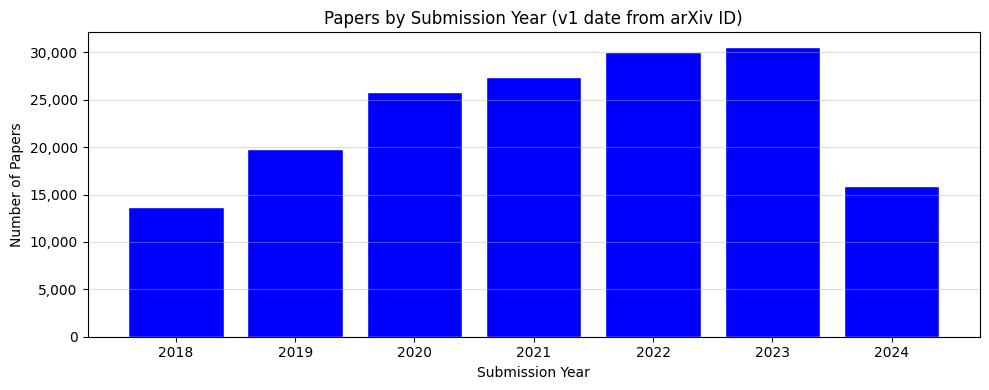

year
2018    13724
2019    19781
2020    25860
2021    27394
2022    30030
2023    30586
2024    15900


In [7]:
def plot_year_distribution(df: pd.DataFrame) -> None:
    """Bar chart of paper count per submission year."""
    counts = df["year"].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(counts.index.astype(str), counts.values, color="blue", edgecolor="white")
    ax.set_xlabel("Submission Year")
    ax.set_ylabel("Number of Papers")
    ax.set_title("Papers by Submission Year (v1 date from arXiv ID)")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(counts.to_string())


plot_year_distribution(df_papers_f)

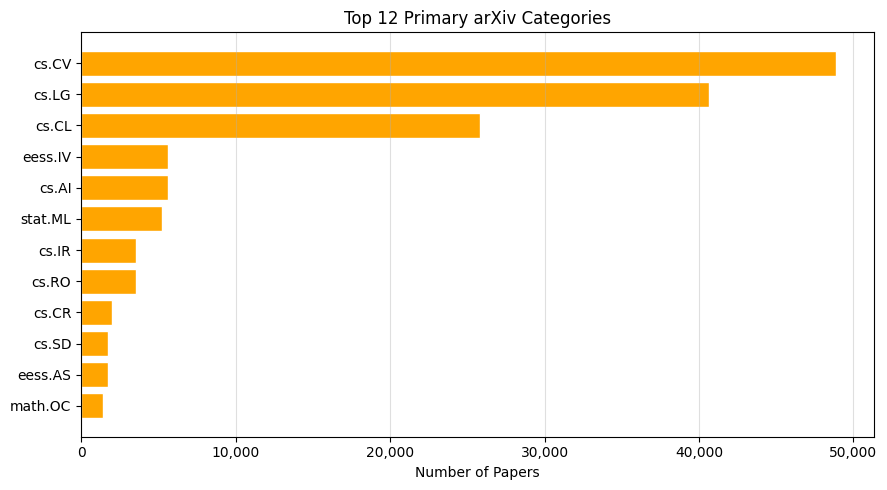

In [8]:
def plot_category_distribution(df: pd.DataFrame, top_n: int = 12) -> None:
    """Horizontal bar chart of the top-N primary arXiv categories."""
    counts = df["primary_cat"].value_counts().head(top_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(counts.index[::-1], counts.values[::-1], color="orange", edgecolor="white")
    ax.set_xlabel("Number of Papers")
    ax.set_title(f"Top {top_n} Primary arXiv Categories")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x", alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_category_distribution(df_papers_f)

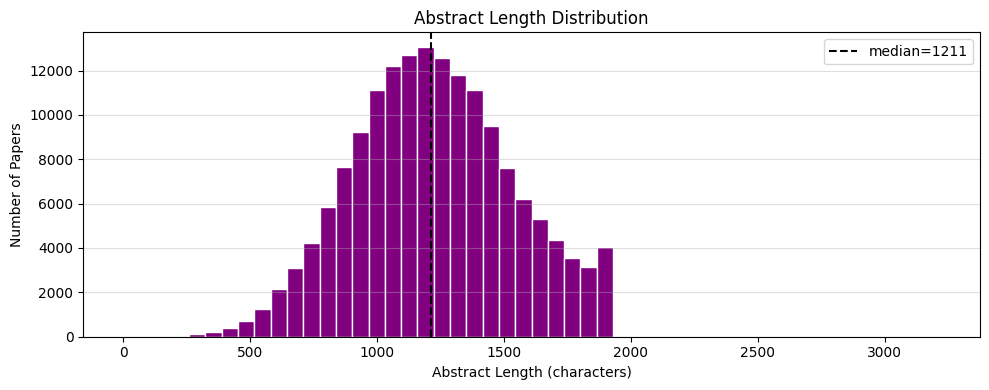

abstract length stats:
count    163275
mean       1221
std         316
min           3
25%        1001
50%        1211
75%        1433
max        3214
Name: abstract, dtype: int64


In [9]:
def plot_abstract_lengths(df: pd.DataFrame) -> None:
    """Histogram of abstract character lengths to check for truncation or stubs."""
    lengths = df["abstract"].str.len()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(lengths, bins=50, color="purple", edgecolor="white")
    ax.set_xlabel("Abstract Length (characters)")
    ax.set_ylabel("Number of Papers")
    ax.set_title("Abstract Length Distribution")
    ax.axvline(lengths.median(), color="black", linestyle="--", label=f"median={lengths.median():.0f}")
    ax.legend()
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"abstract length stats:\n{lengths.describe().round(0).astype(int)}")


plot_abstract_lengths(df_papers_f)

In [10]:
# I checked which S2 fields of study appeared most often in the dataset.
# This told us whether the papers were actually from the right domain.
s2_field_counts = (
    df_papers_f["s2_fields"]
    .str.split(", ")
    .explode()
    .loc[lambda s: s.str.len() > 0]
    .value_counts()
)
print("top S2 fields of study:")
print(s2_field_counts.head(10).to_string())
print(f"\npapers with no S2 field: {(df_papers_f['s2_fields'].str.len() == 0).sum():,}")

top S2 fields of study:
s2_fields
Computer Science     162615
Mathematics           34409
Engineering           19813
Medicine              11017
Physics                6033
Biology                2421
Economics               938
Psychology              373
Materials Science       119
Sociology                75

papers with no S2 field: 0


In [11]:
# I measured what fraction of raw S2 links stayed in-sample after filtering.
# A low number (under 1%) would mean the paper set was too small for good CF performance,
# so we would need to increase MAX_PAPERS.
total_in = len(df_cit_f)
papers_citing = df_cit_f["source_id"].nunique()
papers_cited  = df_cit_f["target_id"].nunique()

if not SKIP_PIPELINE:
    total_raw = len(df_citations_raw)
    pct_in = 100 * total_in / total_raw if total_raw > 0 else 0
    print(f"raw citation links     : {total_raw:,}")
    print(f"in-sample links        : {total_in:,} ({pct_in:.2f}%)")
    if pct_in < 1.0:
        print("note: coverage under 1% - consider MIN_YEAR=2015 or MAX_PAPERS=100_000")
else:
    print("(raw S2 link count not available when loaded from saved dataset)")
    print(f"in-sample links        : {total_in:,}")

print(f"papers that cite others: {papers_citing:,} ({100*papers_citing/n_papers:.1f}%)")
print(f"papers that get cited  : {papers_cited:,} ({100*papers_cited/n_papers:.1f}%)")

(raw S2 link count not available when loaded from saved dataset)
in-sample links        : 1,910,207
papers that cite others: 110,989 (68.0%)
papers that get cited  : 132,989 (81.5%)


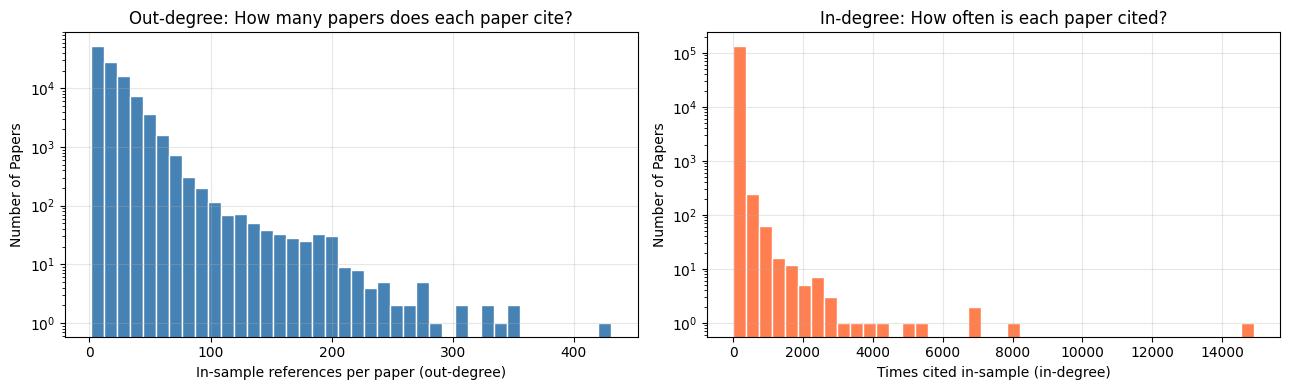

out-degree stats:
count    110989.00
mean         17.21
std          17.57
min           1.00
25%           5.00
50%          12.00
75%          24.00
max         431.00

in-degree stats:
count    132989.00
mean         14.36
std          78.75
min           1.00
25%           2.00
50%           4.00
75%          11.00
max       14911.00


In [12]:
def plot_degree_distributions(df_cit: pd.DataFrame) -> None:
    """
    Side-by-side histograms of in-degree and out-degree.

    I used log scale on the y-axis because citation graphs follow a power law:
    most papers have very few citations and a small number have many. Log scale
    made that long tail visible to us rather than squashing it against zero.
    """
    out_degree = df_cit.groupby("source_id")["target_id"].count()
    in_degree = df_cit.groupby("target_id")["source_id"].count()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(out_degree, bins=40, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("In-sample references per paper (out-degree)")
    axes[0].set_ylabel("Number of Papers")
    axes[0].set_title("Out-degree: How many papers does each paper cite?")
    axes[0].set_yscale("log")
    axes[0].grid(alpha=0.3)

    axes[1].hist(in_degree, bins=40, color="coral", edgecolor="white")
    axes[1].set_xlabel("Times cited in-sample (in-degree)")
    axes[1].set_ylabel("Number of Papers")
    axes[1].set_title("In-degree: How often is each paper cited?")
    axes[1].set_yscale("log")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("out-degree stats:")
    print(out_degree.describe().round(2).to_string())
    print("\nin-degree stats:")
    print(in_degree.describe().round(2).to_string())


plot_degree_distributions(df_cit_f)

In [13]:
def print_top_cited(df_papers: pd.DataFrame, df_cit: pd.DataFrame, top_n: int = 10) -> None:
    """
    Print the top-N most cited papers in the dataset.

    I used this as a sanity check. If I recognized landmark papers like Attention
    Is All You Need near the top, we could trust that the citation data was correct.
    """
    in_counts = df_cit["target_id"].value_counts().head(top_n)
    id_to_title = dict(zip(df_papers["arxiv_id"], df_papers["title"]))

    print(f"top {top_n} most cited papers in this dataset:")
    print("-" * 70)
    for rank, (arxiv_id, count) in enumerate(in_counts.items(), start=1):
        title = id_to_title.get(arxiv_id, "(title not found)")
        print(f"{rank:2}. [{count:4d} citations]  {arxiv_id}")
        print(f"    {title[:80]}")


print_top_cited(df_papers_f, df_cit_f)

top 10 most cited papers in this dataset:
----------------------------------------------------------------------
 1. [14911 citations]  1810.04805
    BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding
 2. [8047 citations]  2005.14165
    Language Models are Few-Shot Learners
 3. [6930 citations]  1912.01703
    PyTorch: An Imperative Style, High-Performance Deep Learning Library
 4. [6728 citations]  2010.11929
    An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale
 5. [5311 citations]  2103.00020
    Learning Transferable Visual Models From Natural Language Supervision
 6. [4853 citations]  1907.11692
    RoBERTa: A Robustly Optimized BERT Pretraining Approach
 7. [4473 citations]  1910.10683
    Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transforme
 8. [3836 citations]  2002.05709
    A Simple Framework for Contrastive Learning of Visual Representations
 9. [3359 citations]  2203.00667
    Generative Ad

In [14]:
# I computed sparsity to understand how much signal the CF models would have.
# More density gives us better collaborative filtering, but citation graphs are
# always very sparse. Typical recommendation datasets sit at 99%+ sparsity.
n_p = len(df_papers_f)
n_c = len(df_cit_f)
density = n_c / (n_p * n_p)
sparsity = 1 - density

print(f"citation matrix size : {n_p:,} x {n_p:,}")
print(f"non-zero entries     : {n_c:,}")
print(f"density              : {density:.6f} ({100*density:.4f}%)")
print(f"sparsity             : {sparsity:.6f} ({100*sparsity:.4f}%)")

citation matrix size : 163,275 x 163,275
non-zero entries     : 1,910,207
density              : 0.000072 (0.0072%)
sparsity             : 0.999928 (99.9928%)


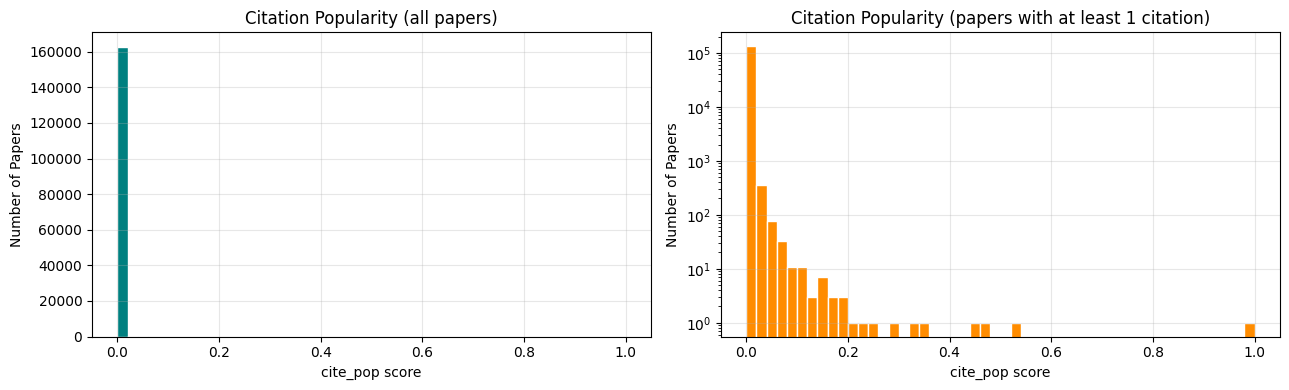

papers with cite_pop = 0 (never cited in-sample): 18.5%


In [15]:
def plot_citation_popularity(df: pd.DataFrame) -> None:
    """Distribution of the cite_pop score (0 to 1). Most papers have low scores."""
    nonzero = df[df["cite_pop"] > 0]["cite_pop"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(df["cite_pop"], bins=50, color="teal", edgecolor="white")
    axes[0].set_xlabel("cite_pop score")
    axes[0].set_ylabel("Number of Papers")
    axes[0].set_title("Citation Popularity (all papers)")
    axes[0].grid(alpha=0.3)

    if len(nonzero) > 0:
        axes[1].hist(nonzero, bins=50, color="darkorange", edgecolor="white")
        axes[1].set_xlabel("cite_pop score")
        axes[1].set_ylabel("Number of Papers")
        axes[1].set_title("Citation Popularity (papers with at least 1 citation)")
        axes[1].set_yscale("log")
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    zero_pct = 100 * (df["cite_pop"] == 0).mean()
    print(f"papers with cite_pop = 0 (never cited in-sample): {zero_pct:.1f}%")


plot_citation_popularity(df_papers_f)

In [16]:
# Final summary card for the dataset.
print("=" * 55)
print(" FINAL DATASET SUMMARY")
print("=" * 55)
print(f"  Papers             : {len(df_papers_f):>8,}")
print(f"  Citation links     : {len(df_cit_f):>8,}")
print(f"  Avg refs/paper     : {len(df_cit_f)/len(df_papers_f):>8.1f}")
print(f"  Matrix density     : {100*density:>8.4f}%")
print(f"  Year range         :   {df_papers_f['year'].min()} - {df_papers_f['year'].max()}")
print(f"  S2 field coverage  : {(df_papers_f['s2_fields'].str.len()>0).mean():>8.1%}")
print(f"  Papers never cited : {(df_papers_f['cite_pop']==0).sum():>8,}")
print("=" * 55)
print()
print("files saved:")
for fname in ["papers.csv", "citations.csv", "citation_pop.csv"]:
    fpath = OUTPUT_DIR / fname
    if fpath.exists():
        size_mb = fpath.stat().st_size / 1e6
        print(f"  {fname:<22} {size_mb:.1f} MB")

 FINAL DATASET SUMMARY
  Papers             :  163,275
  Citation links     : 1,910,207
  Avg refs/paper     :     11.7
  Matrix density     :   0.0072%
  Year range         :   2018 - 2024
  S2 field coverage  :   100.0%
  Papers never cited :   30,286

files saved:
  papers.csv             462.2 MB
  citations.csv          66.2 MB
  citation_pop.csv       4.7 MB


---
## Section 5 — Baseline Model: TF-IDF Content Similarity

I built a TF-IDF cosine similarity baseline to quantify how much citation-structure information
the graph-based CF models add over pure content matching.

**Approach:**
1. Vectorize each paper's `text` field (title × 2 + abstract) with TF-IDF
2. Hold out 20% of citation edges as the test set
3. For each query paper, rank all other papers by cosine similarity
4. Evaluate top-K recommendations against the held-out citations

**Why this baseline matters:** If TF-IDF already achieves high Precision@K, the papers most
similar in vocabulary are already the ones cited together — content alone explains citation
structure. If TF-IDF scores are low, there is room for collaborative filtering models to improve
by exploiting structural signals that text misses.

| Metric | What it measures |
|---|---|
| **Precision@K** | What fraction of the top-K recommendations are actual citations? |
| **Recall@K** | What fraction of the true citations did we find in the top-K? |
| **NDCG@K** | How well ranked are the relevant results? (penalizes hits ranked lower) |
| **Hit Rate@K** | Does at least one true citation appear in the top-K? |
| **MRR** | Where is the first true citation in the ranked list? |

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# I used 50k features to balance vocabulary coverage with memory footprint.
# sublinear_tf=True applies log(1+tf) to dampen very frequent terms.
# min_df=3 drops terms appearing in fewer than 3 papers (noise / typos).
# Bigrams (1,2) capture phrases like "neural network" and "language model".
# norm="l2" means each row has unit norm, so dot product equals cosine similarity.
vectorizer = TfidfVectorizer(
    max_features=50_000,
    min_df=3,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2",
)
tfidf_matrix = vectorizer.fit_transform(df_papers_f["text"].fillna(""))

print(f"TF-IDF matrix : {tfidf_matrix.shape[0]:,} papers × {tfidf_matrix.shape[1]:,} terms")
print(f"non-zeros     : {tfidf_matrix.nnz:,}")
print(f"sparsity      : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")

TF-IDF matrix : 163,275 papers × 50,000 terms
non-zeros     : 33,836,875
sparsity      : 99.5855%


In [18]:
# I held out 20% of citation edges at random to use as the test set.
# Training citations are excluded from the recommendation list so the model
# can't "cheat" by re-recommending already-known links.
np.random.seed(256)
edges = df_cit_f[["source_idx", "target_idx"]].values
perm  = np.random.permutation(len(edges))
split = int(0.8 * len(perm))

train_edges = edges[perm[:split]]
test_edges  = edges[perm[split:]]

train_gt: dict[int, set[int]] = defaultdict(set)
test_gt:  dict[int, set[int]] = defaultdict(set)
for src, tgt in train_edges:
    train_gt[int(src)].add(int(tgt))
for src, tgt in test_edges:
    test_gt[int(src)].add(int(tgt))

print(f"train edges : {len(train_edges):,}")
print(f"test edges  : {len(test_edges):,}")
print(f"test queries (papers with >=1 held-out citation) : {len(test_gt):,}")


# --- metric helpers ---
def _precision_at_k(recs: list, rel: set, k: int) -> float:
    return len(set(recs[:k]) & rel) / k

def _recall_at_k(recs: list, rel: set, k: int) -> float:
    return len(set(recs[:k]) & rel) / len(rel) if rel else 0.0

def _ndcg_at_k(recs: list, rel: set, k: int) -> float:
    dcg  = sum(1.0 / np.log2(i + 2) for i, r in enumerate(recs[:k]) if r in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, len(rel))))
    return dcg / idcg if idcg > 0 else 0.0

def _hit_rate_at_k(recs: list, rel: set, k: int) -> float:
    return 1.0 if set(recs[:k]) & rel else 0.0

def _mrr(recs: list, rel: set) -> float:
    for i, r in enumerate(recs):
        if r in rel:
            return 1.0 / (i + 1)
    return 0.0


# --- evaluate ---
K_VALUES = [5, 10, 20]
K_MAX = max(K_VALUES)

# I sampled up to 1000 query papers so evaluation finishes in a few minutes.
# Papers with fewer than 1 test citation are skipped (nothing to evaluate).
query_papers = [src for src, tgts in test_gt.items() if len(tgts) >= 1]
np.random.shuffle(query_papers)
EVAL_SAMPLE = min(1_000, len(query_papers))
query_papers = query_papers[:EVAL_SAMPLE]

print(f"\nevaluating on {EVAL_SAMPLE:,} query papers …")
LOG_EVERY = 100  # print a progress line every N papers

bucket: dict[int, dict[str, list]] = {
    k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []} for k in K_VALUES
}

t0 = time.monotonic()
for i, q_idx in enumerate(query_papers):
    # tfidf_matrix rows are l2-normalised → dot product == cosine similarity
    scores = (tfidf_matrix[q_idx] @ tfidf_matrix.T).toarray().ravel()
    scores[q_idx] = -np.inf                        # exclude self
    for excl in train_gt.get(q_idx, set()):
        if excl < len(scores):
            scores[excl] = -np.inf                 # exclude training citations

    recs = np.argsort(scores)[::-1][:K_MAX].tolist()
    rel  = test_gt[q_idx]

    for k in K_VALUES:
        bucket[k]["p"].append(_precision_at_k(recs, rel, k))
        bucket[k]["r"].append(_recall_at_k(recs, rel, k))
        bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
        bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
        bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    if (i + 1) % LOG_EVERY == 0 or (i + 1) == EVAL_SAMPLE:
        elapsed = time.monotonic() - t0
        rate    = (i + 1) / elapsed
        eta_s   = (EVAL_SAMPLE - i - 1) / rate if rate > 0 else 0
        p10     = np.mean(bucket[10]["p"]) if bucket[10]["p"] else 0.0
        hr10    = np.mean(bucket[10]["hr"]) if bucket[10]["hr"] else 0.0
        print(
            f"  [{i+1:>4}/{EVAL_SAMPLE}]  "
            f"{elapsed:5.1f}s elapsed  |  "
            f"ETA {eta_s:4.0f}s  |  "
            f"P@10={p10:.4f}  HR@10={hr10:.4f}"
        )

results = {
    k: {
        "Precision": np.mean(bucket[k]["p"]),
        "Recall":    np.mean(bucket[k]["r"]),
        "NDCG":      np.mean(bucket[k]["ndcg"]),
        "Hit Rate":  np.mean(bucket[k]["hr"]),
        "MRR":       np.mean(bucket[k]["mrr"]),
    }
    for k in K_VALUES
}

total_elapsed = time.monotonic() - t0
print(f"\ndone in {total_elapsed:.1f}s  ({total_elapsed/EVAL_SAMPLE*1000:.0f} ms/paper)")

train edges : 1,528,165
test edges  : 382,042
test queries (papers with >=1 held-out citation) : 90,101

evaluating on 1,000 query papers …
  [ 100/1000]  115.5s elapsed  |  ETA 1039s  |  P@10=0.0240  HR@10=0.2400
  [ 200/1000]  244.5s elapsed  |  ETA  978s  |  P@10=0.0270  HR@10=0.2550
  [ 300/1000]  353.5s elapsed  |  ETA  825s  |  P@10=0.0310  HR@10=0.2667
  [ 400/1000]  461.7s elapsed  |  ETA  693s  |  P@10=0.0357  HR@10=0.2975
  [ 500/1000]  573.0s elapsed  |  ETA  573s  |  P@10=0.0338  HR@10=0.2800
  [ 600/1000]  682.8s elapsed  |  ETA  455s  |  P@10=0.0337  HR@10=0.2767
  [ 700/1000]  792.7s elapsed  |  ETA  340s  |  P@10=0.0346  HR@10=0.2814
  [ 800/1000]  896.9s elapsed  |  ETA  224s  |  P@10=0.0334  HR@10=0.2725
  [ 900/1000]  1000.9s elapsed  |  ETA  111s  |  P@10=0.0330  HR@10=0.2722
  [1000/1000]  1100.6s elapsed  |  ETA    0s  |  P@10=0.0329  HR@10=0.2750

done in 1100.6s  (1101 ms/paper)


In [ ]:
# I printed a clean table so we can compare metrics across K values at a glance.
print("TF-IDF Cosine Similarity — Evaluation Results")
print("=" * 58)
header = f"{'Metric':<14}" + "".join(f"{'@'+str(k):>12}" for k in K_VALUES)
print(header)
print("-" * 58)
for metric in ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]:
    row = f"{metric:<14}" + "".join(f"{results[k][metric]:>12.4f}" for k in K_VALUES)
    print(row)
print("=" * 58)
print(f"\nEval set : {EVAL_SAMPLE:,} query papers | "
      f"test edges: {len(test_edges):,} | train edges: {len(train_edges):,}")
print()
print("Interpretation:")
print(f"  Precision@10  {results[10]['Precision']:.4f}  — "
      f"~{results[10]['Precision']*10:.1f} of 10 recommendations are true citations")
print(f"  Hit Rate@10   {results[10]['Hit Rate']:.4f}  — "
      f"at least 1 correct citation found in top-10 for "
      f"{results[10]['Hit Rate']*100:.1f}% of queries")
print(f"  NDCG@10       {results[10]['NDCG']:.4f}  — "
      f"{'good' if results[10]['NDCG'] > 0.15 else 'low'} ranking quality "
      f"(random baseline ≈ 0.001)")

TF-IDF Cosine Similarity — Evaluation Results
Metric                  @5         @10         @20
----------------------------------------------------------
Precision           0.0438      0.0328      0.0243
Recall              0.0760      0.1071      0.1529
NDCG                0.0751      0.0843      0.1001
Hit Rate            0.1950      0.2750      0.3700
MRR                 0.1201      0.1309      0.1377

Eval set : 1,000 query papers | test edges: 382,042 | train edges: 1,528,165

Interpretation:
  Precision@10  0.0328  — ~0.3 of 10 recommendations are true citations
  Hit Rate@10   0.2750  — at least 1 correct citation found in top-10 for 27.5% of queries
  NDCG@10       0.0843  — low ranking quality (random baseline ≈ 0.001)


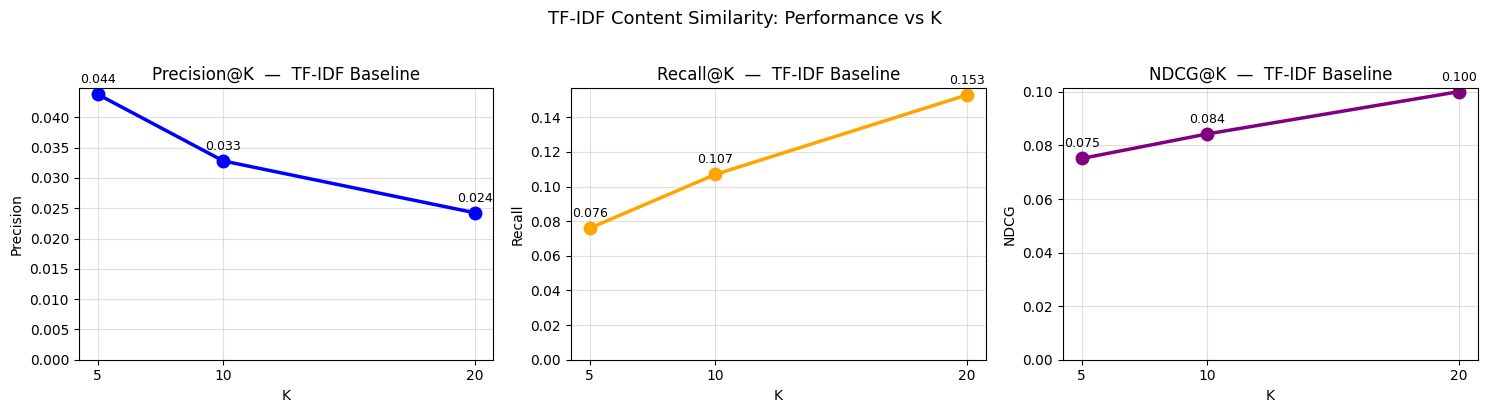

saved to baseline_metrics.png


In [ ]:
# Plotted the three primary metrics across K so we can visualise where the baseline
# starts to saturate and how much room the CF models have to improve.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_colors = [("Precision", "blue"), ("Recall", "orange"), ("NDCG", "purple")]

for ax, (metric, color) in zip(axes, metric_colors):
    vals = [results[k][metric] for k in K_VALUES]
    ax.plot(K_VALUES, vals, marker="o", linewidth=2.5, color=color, markersize=9)
    for k, v in zip(K_VALUES, vals):
        ax.annotate(f"{v:.3f}", (k, v), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=9)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K  —  TF-IDF Baseline")
    ax.set_xticks(K_VALUES)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.4)

plt.suptitle("TF-IDF Content Similarity: Performance vs K", fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "baseline_metrics.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("saved to baseline_metrics.png")

In [19]:
# Picked a random paper and showed what TF-IDF recommends for it.
# Recognising relevant papers in the top-10 is a quick sanity check that the
# model is doing something sensible before we look at aggregate metrics.
np.random.seed(42)
sample_idx = int(np.random.choice(df_papers_f["paper_idx"].values))
sample_row = df_papers_f.set_index("paper_idx").loc[sample_idx]

print("Query paper:")
print(f"  arXiv ID : {sample_row['arxiv_id']}")
print(f"  Year     : {sample_row['year']}")
print(f"  Category : {sample_row['primary_cat']}")
print(f"  Title    : {sample_row['title'][:100]}")
print()

scores = (tfidf_matrix[sample_idx] @ tfidf_matrix.T).toarray().ravel()
scores[sample_idx] = -np.inf  # exclude self
top10_idx = np.argsort(scores)[::-1][:10]

id_to_row = df_papers_f.set_index("paper_idx")
actual_citations = set(df_cit_f[df_cit_f["source_idx"] == sample_idx]["target_idx"])

print("Top-10 TF-IDF recommendations  (* = actual citation in dataset):")
print("-" * 72)
for rank, idx in enumerate(top10_idx, start=1):
    row  = id_to_row.loc[idx]
    sim  = scores[idx]
    flag = " *" if idx in actual_citations else ""
    print(f"{rank:2}.{flag} [sim={sim:.3f}] {row['arxiv_id']} ({row['year']}, {row['primary_cat']})")
    print(f"     {row['title'][:80]}")

Query paper:
  arXiv ID : 2305.12420
  Year     : 2023
  Category : cs.IR
  Title    : Multi-factor Sequential Re-ranking with Perception-Aware Diversification

Top-10 TF-IDF recommendations  (* = actual citation in dataset):
------------------------------------------------------------------------
 1. [sim=0.233] 2107.05204 (2021, cs.IR)
     Sliding Spectrum Decomposition for Diversified Recommendation
 2. [sim=0.231] 2203.12267 (2022, cs.IR)
     PEAR: Personalized Re-ranking with Contextualized Transformer for Recommendation
 3. [sim=0.222] 2206.05020 (2022, cs.IR)
     Feature-aware Diversified Re-ranking with Disentangled Representations for Relev
 4. [sim=0.220] 2112.07621 (2021, cs.IR)
     Re-ranking With Constraints on Diversified Exposures for Homepage Recommender Sy
 5. [sim=0.208] 1904.06813 (2019, cs.IR)
     Personalized Re-ranking for Recommendation
 6. [sim=0.197] 1908.10171 (2019, cs.IR)
     Improving End-to-End Sequential Recommendations with Intent-aware Diversifica

## Section 6: Advanced Models

### SVD:
Notes:
- "User" is the source paper and the "Item" is the cited paper
- rows: Your original paper_id list (The "Seekers")
- cols: The unique cited_paper_id list (The "References")
- values: binary (1 if a citation exists, 0 otherwise)
- By decomposing this matrix, SVD finds "Latent Factors."
- If Paper A and Paper B cite many of the same things, they will have similar vectors in the latent space. This allows you to recommend a paper that Paper A should have cited because it fits the mathematical "neighborhood" of its other citations.
- Using truncatedSVD since our matrix is huge, so its limited to 128 fac, can increase if needed.
- this model good for sparse matrices from what i can see; also surprise svd better for user x item rating preds rather than the way we r using, cuz 1 = citation exist and 0 unkwown

In [29]:
## SVD Citation Recommender:

n_papers = len(df_papers_f)

A_train = csr_matrix((np.ones(len(train_edges), dtype=np.float32),(train_edges[:, 0], train_edges[:, 1])),shape=(n_papers, n_papers))

print(f"citation matrix shape : {A_train.shape}")
print(f"non-zeros             : {A_train.nnz:,}")

## train SVD model
N_COMPONENTS = 128

t0 = time.monotonic()

svd = TruncatedSVD(n_components=N_COMPONENTS,random_state=256)

paper_embeddings = svd.fit_transform(A_train)

elapsed = time.monotonic() - t0

print(f"done in {elapsed:.1f}s")
print(f"embedding shape : {paper_embeddings.shape}")


citation matrix shape : (163275, 163275)
non-zeros             : 1,528,165
done in 35.3s
embedding shape : (163275, 128)


In [30]:
#eval
query_papers = [src for src, tgts in test_gt.items() if len(tgts) >= 1]
np.random.shuffle(query_papers)

EVAL_SAMPLE = min(1_000, len(query_papers))
query_papers = query_papers[:EVAL_SAMPLE]

print(f"\nevaluating on {EVAL_SAMPLE:,} query papers ...")

bucket = {
    k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []}
    for k in K_VALUES
}

LOG_EVERY = 100
t0 = time.monotonic()

for i, q_idx in enumerate(query_papers):
    #latent sim scores
    scores = paper_embeddings[q_idx] @ paper_embeddings.T

    #exclude self
    scores[q_idx] = -np.inf

    #exclude training citations
    for excl in train_gt.get(q_idx, set()):
        if excl < len(scores):
            scores[excl] = -np.inf

    #top k reccs
    recs = np.argsort(scores)[::-1][:K_MAX].tolist()

    rel = test_gt[q_idx]

    for k in K_VALUES:
        bucket[k]["p"].append(_precision_at_k(recs, rel, k))
        bucket[k]["r"].append(_recall_at_k(recs, rel, k))
        bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
        bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
        bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    if (i + 1) % LOG_EVERY == 0 or (i + 1) == EVAL_SAMPLE:

        elapsed = time.monotonic() - t0
        rate = (i + 1) / elapsed
        eta_s = (EVAL_SAMPLE - i - 1) / rate if rate > 0 else 0

        p10 = np.mean(bucket[10]["p"])
        hr10 = np.mean(bucket[10]["hr"])

        print(
            f"  [{i+1:>4}/{EVAL_SAMPLE}]  "
            f"{elapsed:5.1f}s elapsed  |  "
            f"ETA {eta_s:4.0f}s  |  "
            f"P@10={p10:.4f}  HR@10={hr10:.4f}"
        )


evaluating on 1,000 query papers ...
  [ 100/1000]    3.2s elapsed  |  ETA   29s  |  P@10=0.0050  HR@10=0.0500
  [ 200/1000]    6.7s elapsed  |  ETA   27s  |  P@10=0.0050  HR@10=0.0500
  [ 300/1000]   10.7s elapsed  |  ETA   25s  |  P@10=0.0053  HR@10=0.0533
  [ 400/1000]   14.5s elapsed  |  ETA   22s  |  P@10=0.0048  HR@10=0.0475
  [ 500/1000]   18.4s elapsed  |  ETA   18s  |  P@10=0.0040  HR@10=0.0400
  [ 600/1000]   21.8s elapsed  |  ETA   15s  |  P@10=0.0037  HR@10=0.0367
  [ 700/1000]   25.4s elapsed  |  ETA   11s  |  P@10=0.0037  HR@10=0.0371
  [ 800/1000]   29.3s elapsed  |  ETA    7s  |  P@10=0.0039  HR@10=0.0387
  [ 900/1000]   32.5s elapsed  |  ETA    4s  |  P@10=0.0040  HR@10=0.0389
  [1000/1000]   35.7s elapsed  |  ETA    0s  |  P@10=0.0043  HR@10=0.0400


In [31]:
#results
results_svd = {
    k: {
        "Precision": np.mean(bucket[k]["p"]),
        "Recall":    np.mean(bucket[k]["r"]),
        "NDCG":      np.mean(bucket[k]["ndcg"]),
        "Hit Rate":  np.mean(bucket[k]["hr"]),
        "MRR":       np.mean(bucket[k]["mrr"]),
    }
    for k in K_VALUES
}

total_elapsed = time.monotonic() - t0

print(f"\ndone in {total_elapsed:.1f}s")

#table across @ k
print("\nSVD Citation Recommender — Evaluation Results")
print("=" * 58)

header = f"{'Metric':<14}" + "".join(f"{'@'+str(k):>12}" for k in K_VALUES)
print(header)

print("-" * 58)

for metric in ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]:
    row = f"{metric:<14}" + "".join(
        f"{results_svd[k][metric]:>12.4f}" for k in K_VALUES
    )
    print(row)

print("=" * 58)


done in 80.5s

SVD Citation Recommender — Evaluation Results
Metric                  @5         @10         @20
----------------------------------------------------------
Precision           0.0046      0.0043      0.0032
Recall              0.0035      0.0072      0.0102
NDCG                0.0050      0.0060      0.0072
Hit Rate            0.0230      0.0400      0.0600
MRR                 0.0111      0.0133      0.0146


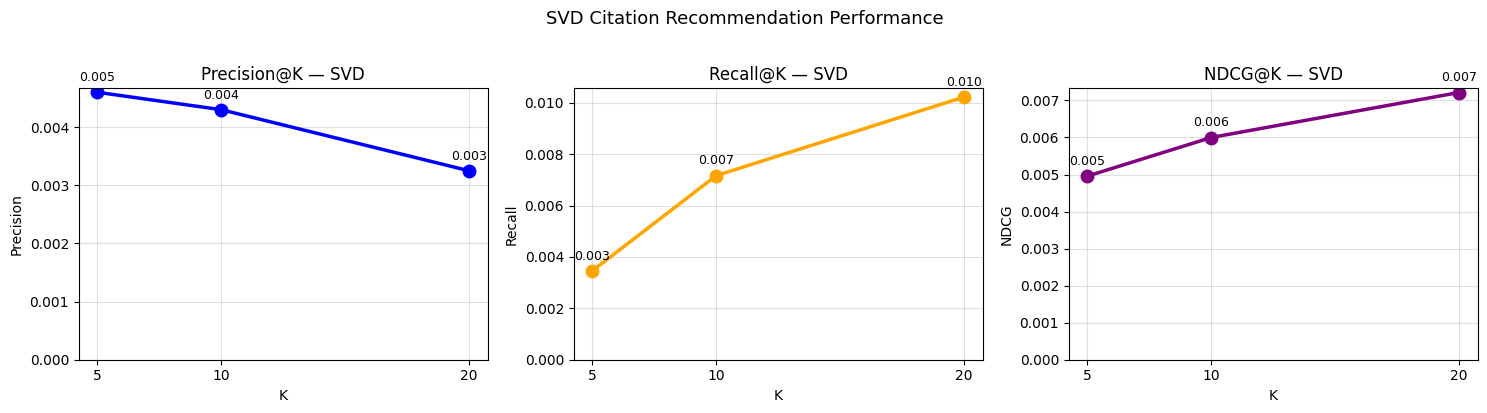

In [32]:
#plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_colors = [
    ("Precision", "blue"),
    ("Recall", "orange"),
    ("NDCG", "purple")
]

for ax, (metric, color) in zip(axes, metric_colors):

    vals = [results_svd[k][metric] for k in K_VALUES]

    ax.plot(
        K_VALUES,
        vals,
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=9
    )

    for k, v in zip(K_VALUES, vals):
        ax.annotate(
            f"{v:.3f}",
            (k, v),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )

    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K — SVD")
    ax.set_xticks(K_VALUES)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.4)

plt.suptitle("SVD Citation Recommendation Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### PageRank & Personlized PageRank w MonteCarlo

- directed acyclic Graph/ dag
— Nodes: Every unique arXiv ID (both sources and targets).
- Edges: A directed arrow from paper_id --> cited_paper_id.
- logic/why it applies here: (In-Degree): How many papers cite this paper? (Standard popularity).
- PageRank: A paper is "important" if it is cited by other important papers.
- why PPR vs standard PR: Standard PR might just give you "famous" papers, while PPR restarts frequently at query paper and focuses on important relative to that paper --> this should help w cross-domain aspect

In [35]:
#citation graph
G = nx.DiGraph()
G.add_edges_from(train_edges)

print(f"nodes : {G.number_of_nodes():,}")
print(f"edges : {G.number_of_edges():,}")

#pagerank
t0 = time.monotonic()

#using the dampening param
pr_scores = nx.pagerank(G,alpha=0.85)

elapsed = time.monotonic() - t0

print(f"done in {elapsed:.1f}s")

#pagerank dict to numpy array
n_papers = len(df_papers_f)

pagerank_vector = np.zeros(n_papers, dtype=np.float32)

for idx, score in pr_scores.items():
    if idx < n_papers:
        pagerank_vector[idx] = score

nodes : 162,069
edges : 1,528,165
done in 6.2s


In [36]:
#evaluation for a random paper
query_papers = [src for src, tgts in test_gt.items() if len(tgts) >= 1]
np.random.shuffle(query_papers)

EVAL_SAMPLE = min(1_000, len(query_papers))
query_papers = query_papers[:EVAL_SAMPLE]

print(f"\nevaluating on {EVAL_SAMPLE:,} query papers ...")

bucket = {
    k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []}
    for k in K_VALUES
}

LOG_EVERY = 100
t0 = time.monotonic()

for i, q_idx in enumerate(query_papers):
    scores = pagerank_vector.copy()

    #exclude self
    scores[q_idx] = -np.inf

    #exclude training ciations
    for excl in train_gt.get(q_idx, set()):
        if excl < len(scores):
            scores[excl] = -np.inf

    #top k recommendations
    recs = np.argsort(scores)[::-1][:K_MAX].tolist()

    rel = test_gt[q_idx]

    for k in K_VALUES:
        bucket[k]["p"].append(_precision_at_k(recs, rel, k))
        bucket[k]["r"].append(_recall_at_k(recs, rel, k))
        bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
        bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
        bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    if (i + 1) % LOG_EVERY == 0 or (i + 1) == EVAL_SAMPLE:

        elapsed = time.monotonic() - t0
        rate = (i + 1) / elapsed
        eta_s = (EVAL_SAMPLE - i - 1) / rate if rate > 0 else 0

        p10 = np.mean(bucket[10]["p"])
        hr10 = np.mean(bucket[10]["hr"])

        print(
            f"  [{i+1:>4}/{EVAL_SAMPLE}]  "
            f"{elapsed:5.1f}s elapsed  |  "
            f"ETA {eta_s:4.0f}s  |  "
            f"P@10={p10:.4f}  HR@10={hr10:.4f}"
        )



evaluating on 1,000 query papers ...
  [ 100/1000]    2.5s elapsed  |  ETA   22s  |  P@10=0.0150  HR@10=0.1400
  [ 200/1000]    4.5s elapsed  |  ETA   18s  |  P@10=0.0115  HR@10=0.1100
  [ 300/1000]    6.6s elapsed  |  ETA   15s  |  P@10=0.0110  HR@10=0.1033
  [ 400/1000]    8.7s elapsed  |  ETA   13s  |  P@10=0.0130  HR@10=0.1225
  [ 500/1000]   10.8s elapsed  |  ETA   11s  |  P@10=0.0120  HR@10=0.1120
  [ 600/1000]   13.1s elapsed  |  ETA    9s  |  P@10=0.0112  HR@10=0.1050
  [ 700/1000]   15.7s elapsed  |  ETA    7s  |  P@10=0.0107  HR@10=0.1000
  [ 800/1000]   18.2s elapsed  |  ETA    5s  |  P@10=0.0105  HR@10=0.0988
  [ 900/1000]   20.3s elapsed  |  ETA    2s  |  P@10=0.0107  HR@10=0.1000
  [1000/1000]   22.3s elapsed  |  ETA    0s  |  P@10=0.0105  HR@10=0.0980


In [37]:
#results
results_pr = {
    k: {
        "Precision": np.mean(bucket[k]["p"]),
        "Recall":    np.mean(bucket[k]["r"]),
        "NDCG":      np.mean(bucket[k]["ndcg"]),
        "Hit Rate":  np.mean(bucket[k]["hr"]),
        "MRR":       np.mean(bucket[k]["mrr"]),
    }
    for k in K_VALUES
}

total_elapsed = time.monotonic() - t0

print(f"\ndone in {total_elapsed:.1f}s")


done in 40.2s


In [38]:
#table across @k
print("\nPageRank Citation Baseline — Evaluation Results")
print("=" * 58)

header = f"{'Metric':<14}" + "".join(f"{'@'+str(k):>12}" for k in K_VALUES)
print(header)

print("-" * 58)

for metric in ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]:
    row = f"{metric:<14}" + "".join(
        f"{results_pr[k][metric]:>12.4f}" for k in K_VALUES
    )
    print(row)

print("=" * 58)


PageRank Citation Baseline — Evaluation Results
Metric                  @5         @10         @20
----------------------------------------------------------
Precision           0.0118      0.0105      0.0074
Recall              0.0195      0.0313      0.0406
NDCG                0.0215      0.0257      0.0291
Hit Rate            0.0580      0.0980      0.1310
MRR                 0.0408      0.0456      0.0476


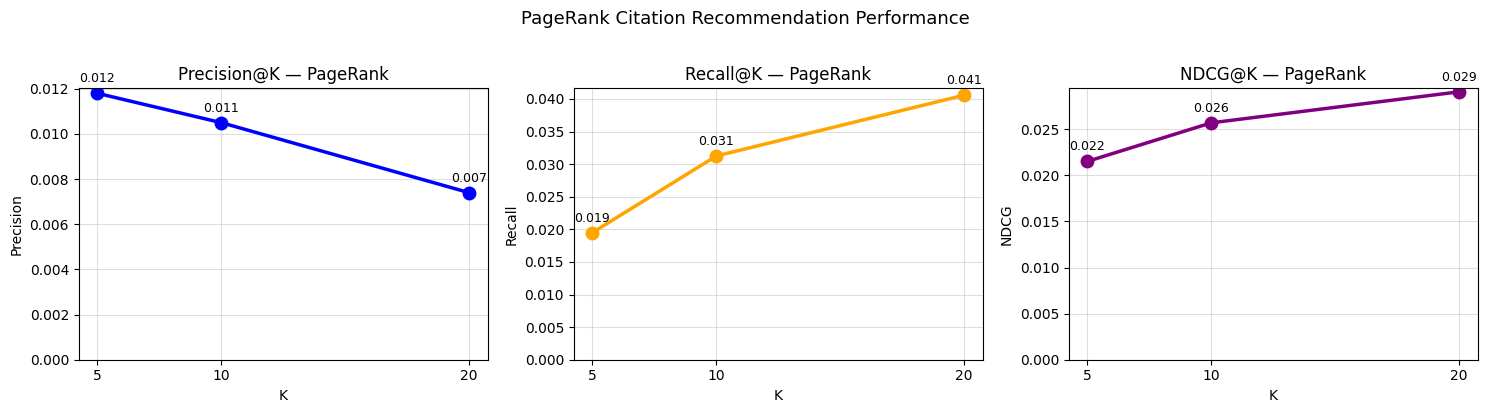

In [39]:
#plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_colors = [
    ("Precision", "blue"),
    ("Recall", "orange"),
    ("NDCG", "purple")
]

for ax, (metric, color) in zip(axes, metric_colors):

    vals = [results_pr[k][metric] for k in K_VALUES]

    ax.plot(
        K_VALUES,
        vals,
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=9
    )

    for k, v in zip(K_VALUES, vals):
        ax.annotate(
            f"{v:.3f}",
            (k, v),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )

    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K — PageRank")
    ax.set_xticks(K_VALUES)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.4)

plt.suptitle("PageRank Citation Recommendation Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

building citation graph ...
nodes : 162,069
edges : 1,528,165

evaluating on 200 query papers ...
  [  25/200]  122.5s elapsed  |  ETA  857s  |  P@10=0.0520  HR@10=0.3600
  [  50/200]  241.0s elapsed  |  ETA  723s  |  P@10=0.0580  HR@10=0.3800
  [  75/200]  361.7s elapsed  |  ETA  603s  |  P@10=0.0560  HR@10=0.3867
  [ 100/200]  481.5s elapsed  |  ETA  481s  |  P@10=0.0630  HR@10=0.4300
  [ 125/200]  602.3s elapsed  |  ETA  361s  |  P@10=0.0576  HR@10=0.3920
  [ 150/200]  720.6s elapsed  |  ETA  240s  |  P@10=0.0550  HR@10=0.3826
  [ 175/200]  842.7s elapsed  |  ETA  120s  |  P@10=0.0534  HR@10=0.3736
  [ 200/200]  962.1s elapsed  |  ETA    0s  |  P@10=0.0533  HR@10=0.3719

done in 962.1s

Personalized PageRank — Evaluation Results
Metric                  @5         @10         @20
----------------------------------------------------------
Precision           0.0613      0.0533      0.0364
Recall              0.0899      0.1394      0.1843
NDCG                0.0957      0.1148      0.

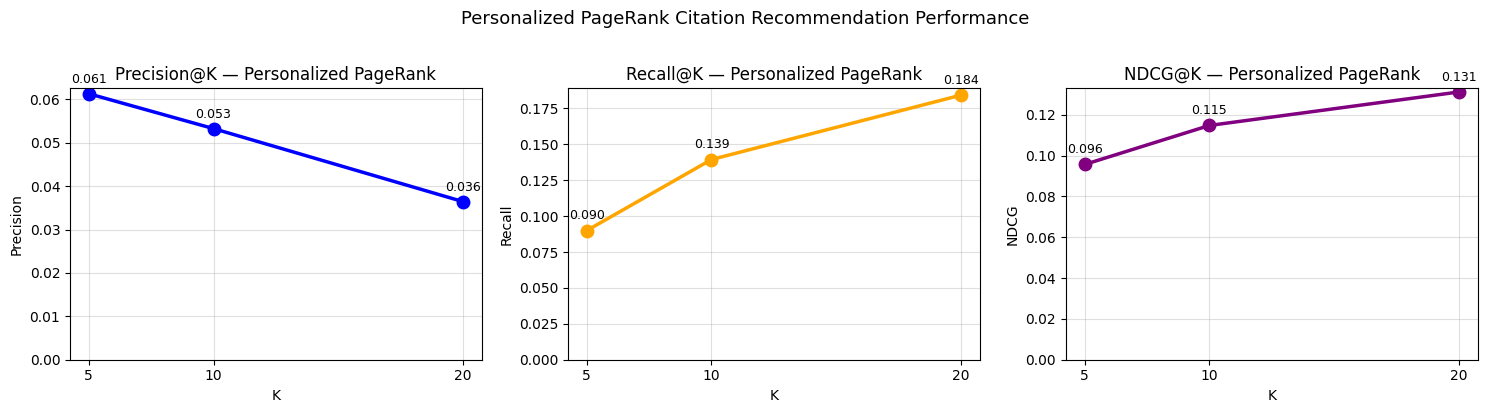

In [40]:
# js ppr, rlly expensive tho

In [ ]:
adj = defaultdict(list)

for src, tgt in train_edges:
    adj[int(src)].append(int(tgt))

n_papers = len(df_papers_f)

print(f"graph nodes: {n_papers:,}")

In [ ]:
#params needed
ALPHA = 0.85
NUM_WALKS = 200        #num of random walks per query
WALK_LEN = 20          #steps per walk

#eval
query_papers = [src for src, tgts in test_gt.items() if len(tgts) >= 1]
np.random.shuffle(query_papers)

EVAL_SAMPLE = min(1000, len(query_papers))
query_papers = query_papers[:EVAL_SAMPLE]

print(f"\nevaluating on {EVAL_SAMPLE:,} query papers ...")

bucket = {
    k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []}
    for k in K_VALUES
}

#ppr w monte carlo
def monte_carlo_ppr(q_idx):
    visits = defaultdict(float)

    for _ in range(NUM_WALKS):

        node = q_idx

        for _ in range(WALK_LEN):
            visits[node] += 1

            if random.random() > ALPHA:
                node = q_idx
                continue

            neighbors = adj.get(node, [])

            if not neighbors:
                node = q_idx
            else:
                node = random.choice(neighbors)

    #normalize scores
    total = sum(visits.values())
    if total == 0:
        return np.zeros(n_papers)

    scores = np.zeros(n_papers, dtype=np.float32)

    for node, count in visits.items():
        if node < n_papers:
            scores[node] = count / total

    return scores

t0 = time.monotonic()

LOG_EVERY = 25

for i, q_idx in enumerate(query_papers):
    scores = monte_carlo_ppr(q_idx)

    #exclude self
    scores[q_idx] = -np.inf

    #exclude training citations
    for excl in train_gt.get(q_idx, set()):
        if excl < len(scores):
            scores[excl] = -np.inf

    #top k recommendations
    recs = np.argsort(scores)[::-1][:K_MAX].tolist()

    rel = test_gt[q_idx]

    for k in K_VALUES:
        bucket[k]["p"].append(_precision_at_k(recs, rel, k))
        bucket[k]["r"].append(_recall_at_k(recs, rel, k))
        bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
        bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
        bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    if (i + 1) % LOG_EVERY == 0 or (i + 1) == EVAL_SAMPLE:

        elapsed = time.monotonic() - t0
        rate = (i + 1) / elapsed
        eta_s = (EVAL_SAMPLE - i - 1) / rate if rate > 0 else 0

        p10 = np.mean(bucket[10]["p"])
        hr10 = np.mean(bucket[10]["hr"])

        print(
            f"  [{i+1:>4}/{EVAL_SAMPLE}]  "
            f"{elapsed:5.1f}s elapsed  |  "
            f"ETA {eta_s:4.0f}s  |  "
            f"P@10={p10:.4f}  HR@10={hr10:.4f}"
        )


In [41]:
#results
results_mc_ppr = {
    k: {
        "Precision": np.mean(bucket[k]["p"]),
        "Recall":    np.mean(bucket[k]["r"]),
        "NDCG":      np.mean(bucket[k]["ndcg"]),
        "Hit Rate":  np.mean(bucket[k]["hr"]),
        "MRR":       np.mean(bucket[k]["mrr"]),
    }
    for k in K_VALUES
}

print("\nMonte Carlo PPR Results")
print("=" * 50)

for metric in ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]:
    print(
        f"{metric:<12}",
        "".join(f"{results_mc_ppr[k][metric]:>10.4f}" for k in K_VALUES)
    )

building adjacency list ...
graph nodes: 163,275

evaluating on 200 query papers ...
  [  25/200]    0.2s elapsed  |  ETA    1s  |  P@10=0.0520  HR@10=0.4400
  [  50/200]    0.4s elapsed  |  ETA    1s  |  P@10=0.0500  HR@10=0.4200
  [  75/200]    0.6s elapsed  |  ETA    1s  |  P@10=0.0507  HR@10=0.4267
  [ 100/200]    0.9s elapsed  |  ETA    1s  |  P@10=0.0490  HR@10=0.4300
  [ 125/200]    1.1s elapsed  |  ETA    1s  |  P@10=0.0456  HR@10=0.4000
  [ 150/200]    1.3s elapsed  |  ETA    0s  |  P@10=0.0460  HR@10=0.3933
  [ 175/200]    1.5s elapsed  |  ETA    0s  |  P@10=0.0446  HR@10=0.3829
  [ 200/200]    1.7s elapsed  |  ETA    0s  |  P@10=0.0440  HR@10=0.3650

Monte Carlo PPR Results
Precision        0.0570    0.0440    0.0355
Recall           0.0931    0.1460    0.2195
NDCG             0.0879    0.1070    0.1337
Hit Rate         0.2550    0.3650    0.5000
MRR              0.1414    0.1555    0.1654


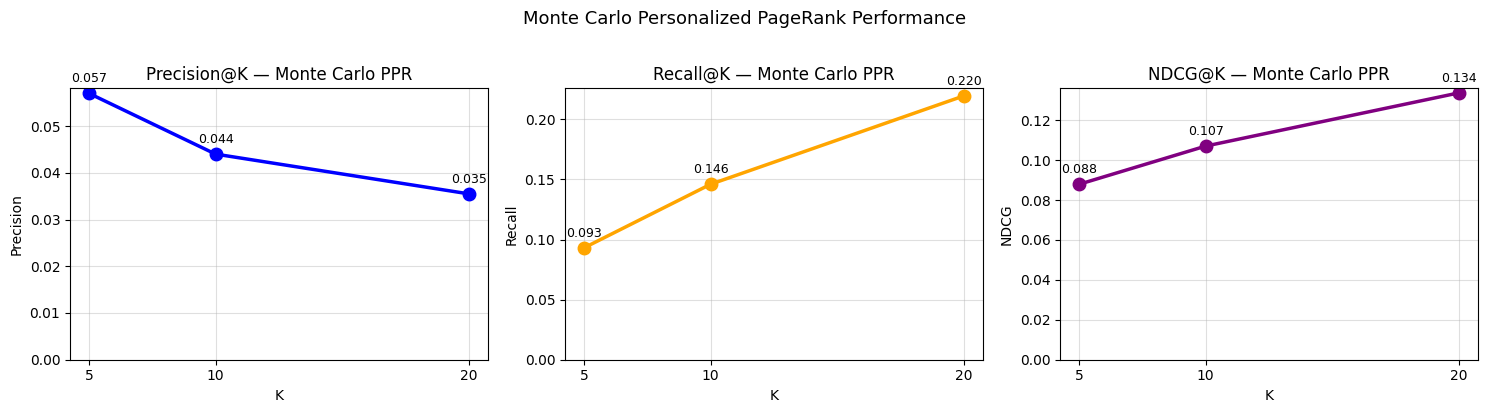

In [42]:
#graphs

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_colors = [
    ("Precision", "blue"),
    ("Recall", "orange"),
    ("NDCG", "purple")
]

for ax, (metric, color) in zip(axes, metric_colors):

    vals = [results_mc_ppr[k][metric] for k in K_VALUES]

    ax.plot(
        K_VALUES,
        vals,
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=9
    )

    for k, v in zip(K_VALUES, vals):
        ax.annotate(
            f"{v:.3f}",
            (k, v),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )

    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K — Monte Carlo PPR")
    ax.set_xticks(K_VALUES)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.4)

plt.suptitle("Monte Carlo Personalized PageRank Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 7: Hybrid Models